In [61]:
# Importing necessary libraries for data analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing machine learning models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Importing classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron

In [105]:
# Loading the Iris dataset
df = pd.read_csv('iris.csv')


In [106]:
# Checking the first few records
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [107]:
# check missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [65]:
# Basic info and stats
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

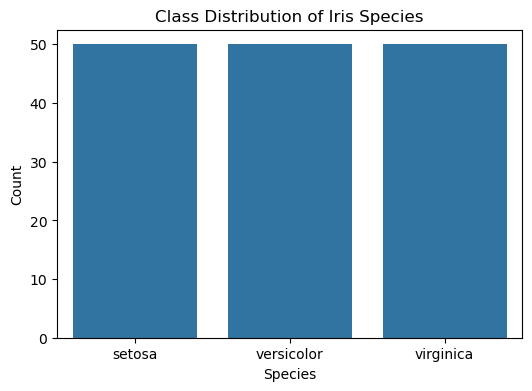

In [66]:
# visulization
plt.figure(figsize=(6, 4))
sns.countplot(x='species', data=df)
plt.title('Class Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

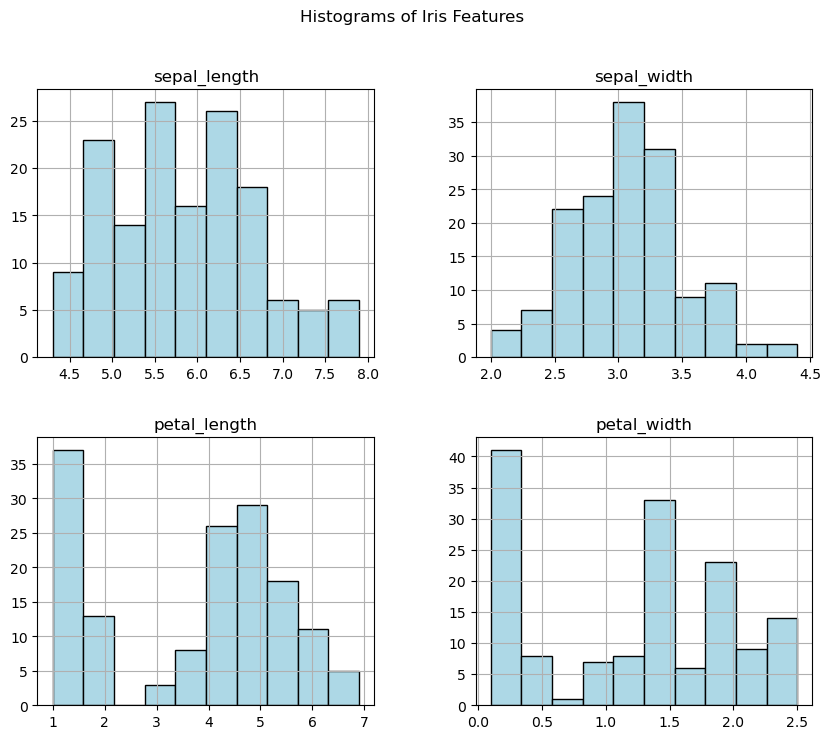

In [67]:
df.drop('species', axis=1).hist(figsize=(10, 8), color='lightblue', edgecolor='black')
plt.suptitle('Histograms of Iris Features')
plt.show()

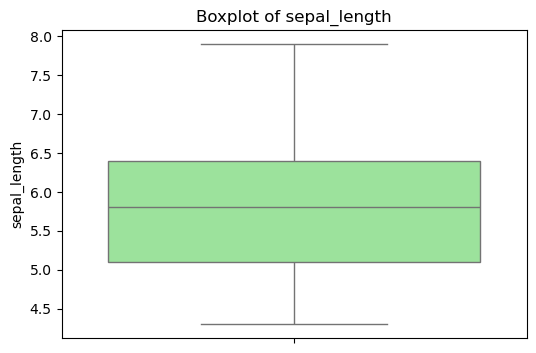

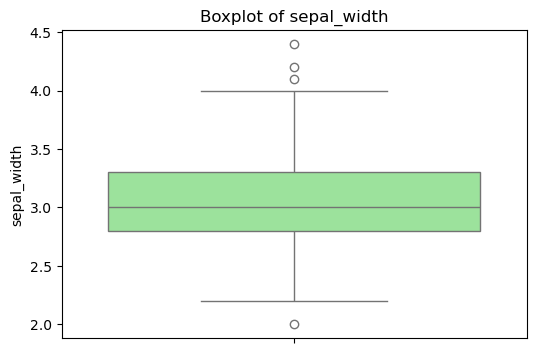

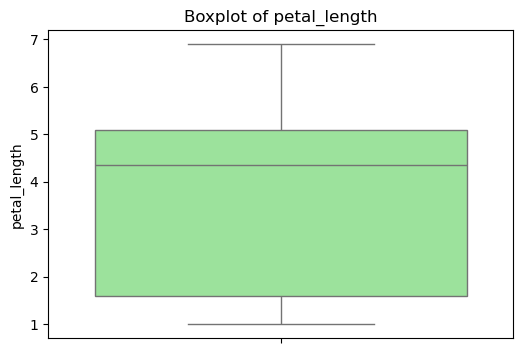

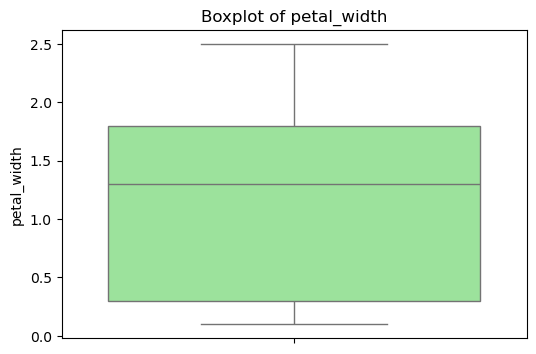

In [68]:
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=col, data=df, color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

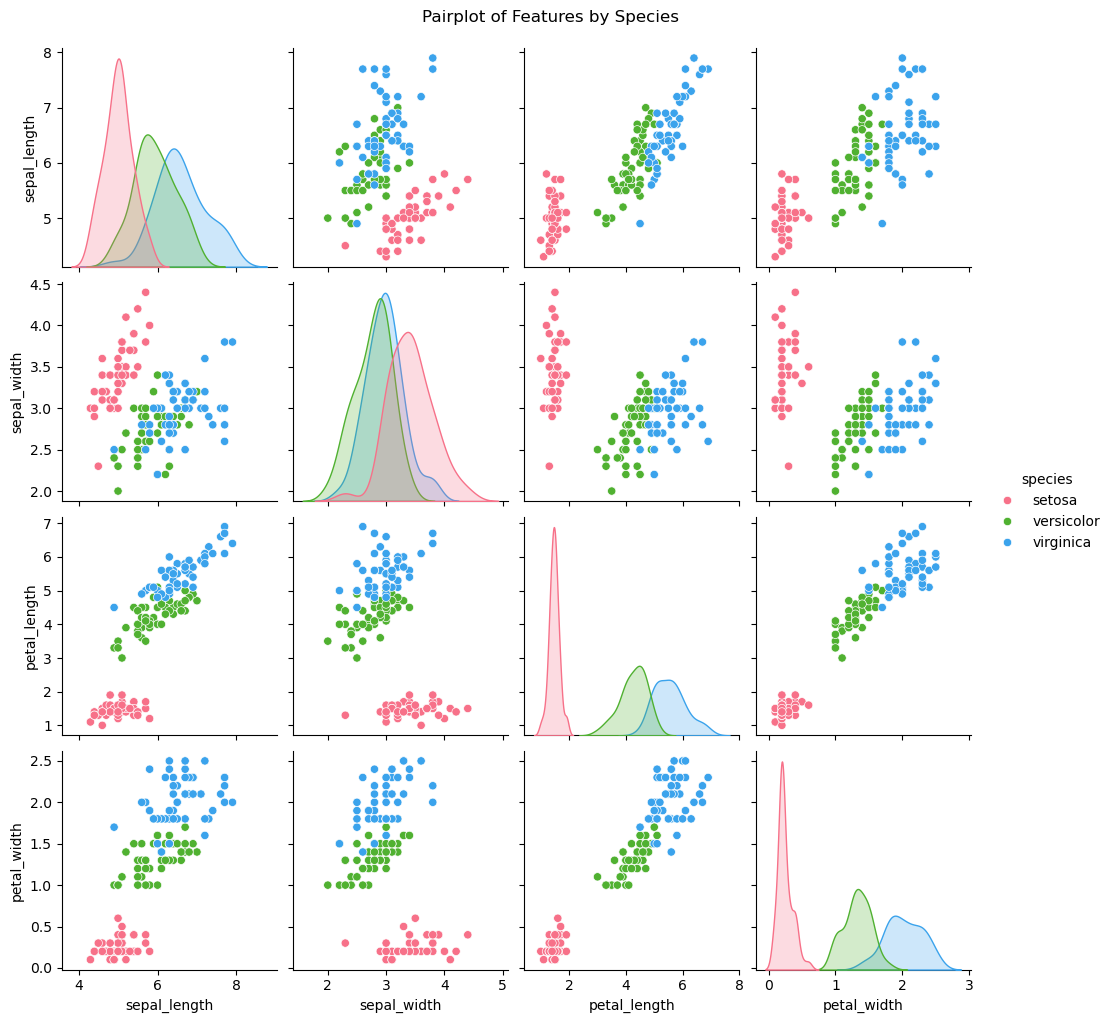

In [69]:
sns.pairplot(df, hue='species', palette='husl')
plt.suptitle('Pairplot of Features by Species', y=1.02)
plt.show()


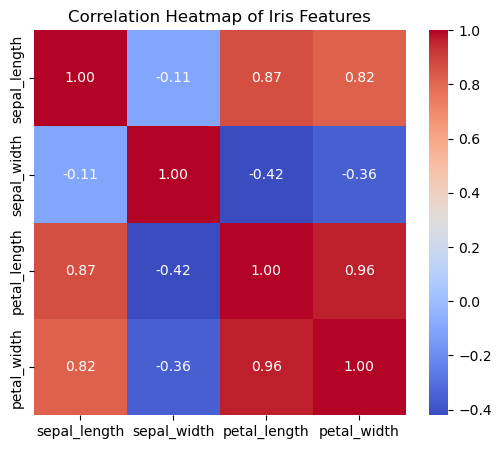

In [70]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Iris Features')
plt.show()

In [71]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop('species', axis=1)  # Features
y = df['species']               # Target

X_scaled = scaler.fit_transform(X)


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [74]:
# Initialize the model
logreg = LogisticRegression(max_iter=200)

In [75]:
# Train the model
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [76]:
# Predict on the test set
y_pred_logreg = logreg.predict(X_test)

In [77]:
# Evaluate accuracy
logreg_acc = accuracy_score(y_test, y_pred_logreg)
print(f'Logistic Regression Accuracy: {logreg_acc:.4f}')

Logistic Regression Accuracy: 1.0000


In [78]:
# Initialize the SVC model
svm = SVC()

In [79]:
# Train the model
svm.fit(X_train, y_train)

SVC()

In [80]:
# Predict on the test set
y_pred_svm = svm.predict(X_test)

In [81]:
# Evaluate accuracy
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f'Support Vector Machine (SVC) Accuracy: {svm_acc:.4f}')

Support Vector Machine (SVC) Accuracy: 1.0000


In [82]:
# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

In [83]:
# Train the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [84]:
# Predict on the test set
y_pred_dt = dt.predict(X_test)

In [85]:
# Evaluate accuracy
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_acc:.4f}')

Decision Tree Accuracy: 1.0000


In [86]:
# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

In [87]:
# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
# Predict on the test set
y_pred_rf = rf.predict(X_test)

In [89]:
# Evaluate accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_acc:.4f}')

Random Forest Accuracy: 1.0000


In [90]:
# Initialize the KNN model
knn = KNeighborsClassifier()

In [91]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [92]:
# Predict on the test set
y_pred_knn = knn.predict(X_test)

In [93]:
# Evaluate accuracy
knn_acc = accuracy_score(y_test, y_pred_knn)
print(f'K-Nearest Neighbors (KNN) Accuracy: {knn_acc:.4f}')

K-Nearest Neighbors (KNN) Accuracy: 1.0000


In [94]:
# Initialize the Naive Bayes model
nb = GaussianNB()

In [95]:

# Train the model
nb.fit(X_train, y_train)

GaussianNB()

In [96]:
# Predict on the test set
y_pred_nb = nb.predict(X_test)

In [97]:
# Evaluate accuracy
nb_acc = accuracy_score(y_test, y_pred_nb)
print(f'Naive Bayes Accuracy: {nb_acc:.4f}')

Naive Bayes Accuracy: 1.0000


In [98]:
# Initialize the Perceptron model
perceptron = Perceptron()

In [99]:
# Train the model
perceptron.fit(X_train, y_train)

Perceptron()

In [100]:
# Predict on the test set
y_pred_perceptron = perceptron.predict(X_test)

In [101]:
# Evaluate accuracy
perceptron_acc = accuracy_score(y_test, y_pred_perceptron)
print(f'Perceptron Accuracy: {perceptron_acc:.4f}')

Perceptron Accuracy: 0.9667


In [102]:
# Create a DataFrame for comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (SVC)', 'Decision Tree', 'Random Forest', 
              'KNN', 'Naive Bayes', 'Perceptron'],
    'Accuracy': [logreg_acc, svm_acc, dt_acc, rf_acc, knn_acc, nb_acc, perceptron_acc]
})

# Sort by accuracy
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)
print(model_comparison)


                 Model  Accuracy
0  Logistic Regression  1.000000
1            SVM (SVC)  1.000000
2        Decision Tree  1.000000
3        Random Forest  1.000000
4                  KNN  1.000000
5          Naive Bayes  1.000000
6           Perceptron  0.966667
